<a href="https://colab.research.google.com/github/tonyranye/random-forest/blob/main/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import yfinance as yf

In [4]:
sp500 = yf.Ticker("^GSPC")

In [5]:
sp500 = sp500.history(period="max")

In [6]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-23 00:00:00-05:00,6901.250000,6916.959961,6819.819824,6837.750000,5638350000,0.0,0.0
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,0.0,0.0
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,0.0,0.0


In [7]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-02-13 00:00:00-05:00', '2026-02-17 00:00:00-05:00',
               '2026-02-18 00:00:00-05:00', '2026-02-19 00:00:00-05:00',
               '2026-02-20 00:00:00-05:00', '2026-02-23 00:00:00-05:00',
               '2026-02-24 00:00:00-05:00', '2026-02-25 00:00:00-05:00',
               '2026-02-26 00:00:00-05:00', '2026-02-27 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24656, freq=None)

<Axes: xlabel='Date'>

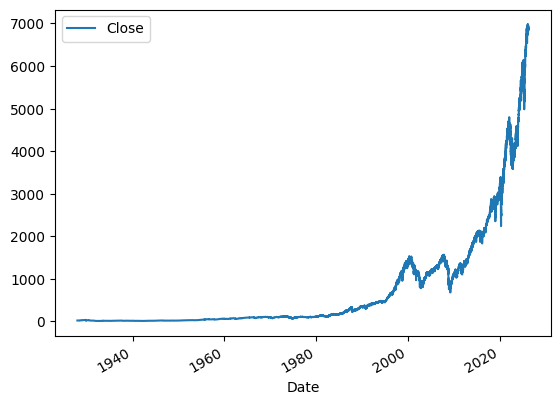

In [8]:
sp500.plot.line(y="Close", use_index=True)

In [9]:
del sp500["Dividends"]
del sp500["Stock Splits"]

In [10]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [11]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-02-23 00:00:00-05:00,6901.250000,6916.959961,6819.819824,6837.750000,5638350000,6890.069824
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863


In [12]:
# Target colum tells us whether tomorrows price will be greater the todays closing price
# 1 if tomorrows if greater, else 0 if tomowwors will be less
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [13]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-02-23 00:00:00-05:00,6901.250000,6916.959961,6819.819824,6837.750000,5638350000,6890.069824,1
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,1
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863,0


In [14]:
# remove data that came before 1990
sp500 = sp500.loc["1990-01-01":].copy()

In [15]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-02-23 00:00:00-05:00,6901.250000,6916.959961,6819.819824,6837.750000,5638350000,6890.069824,1
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,1
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,6908.859863,0


In [16]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [17]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])

In [18]:
import pandas as pd
preds = pd.Series(preds, index=test.index)

In [19]:
precision_score(test["Target"], preds)

0.55

<Axes: xlabel='Date'>

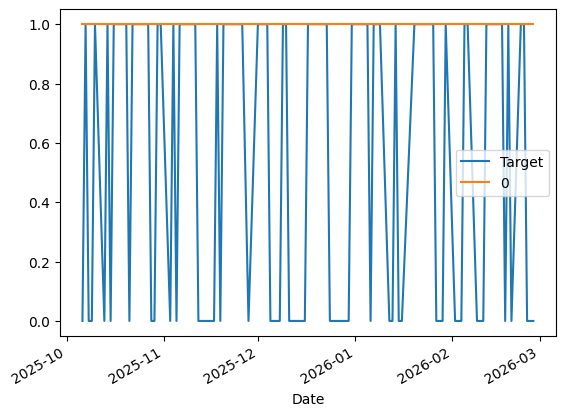

In [20]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [21]:
def predict(train, test, predictors, model):
  model.fit(train[predictors], train["Target"])
  preds = model.predict(test[predictors])
  preds = pd.Series(preds, index=test.index, name="Predictions")
  combined = pd.concat([test["Target"], preds], axis=1)
  return combined

In [22]:
def backtest(data, model, predictors, start=2500, step=250):
  all_predictions = []

  for i in range(start, data.shape[0], step):
    train = data.iloc[0:i].copy()
    test = data.iloc[i: (i+step)].copy()
    preditions = predict(train, test, predictors, model)
    all_predictions.append(preditions)

  return pd.concat(all_predictions)


In [23]:
predictions = backtest(sp500, model, predictors)

In [24]:
predictions["Predictions"].value_counts()

,count
Predictions,
0,3936
1,2670


In [25]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5307116104868914

In [26]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.53739
0,0.46261


In [27]:
horizons = [2, 5, 60, 250, 1000] # mean close prices within theese intervals in trading days, 2 days, trading week 5 days, 3 months, year, 4 years
new_predictors = []

for horizon in horizons:
  rolling_averages = sp500.rolling(horizon).mean()


  ratio_column = f"Close_Ration_{horizon}"
  sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

  trend_column = f"Trend_{horizon}"
  sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

  new_predictors += [ratio_column, trend_column]

In [29]:
sp500 = sp500.dropna()

In [30]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ration_2,Trend_2,Close_Ration_5,Trend_5,Close_Ration_60,Trend_60,Close_Ration_250,Trend_250,Close_Ration_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-20 00:00:00-05:00,6843.259766,6915.859863,6836.330078,6909.509766,5432480000,6837.750000,0,1.003458,1.0,1.006275,4.0,1.003797,34.0,1.090031,143.0,1.357496,536.0
2026-02-23 00:00:00-05:00,6901.250000,6916.959961,6819.819824,6837.750000,5638350000,6890.069824,1,0.994780,1.0,0.995779,3.0,0.993053,33.0,1.078129,143.0,1.342750,535.0
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,6946.129883,1,1.003811,1.0,1.002031,3.0,1.000351,33.0,1.085738,144.0,1.352356,536.0


In [31]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [34]:
def predict(train, test, predictors, model):
  model.fit(train[predictors], train["Target"])
  preds = model.predict_proba(test[predictors])[:,1]
  preds[preds >= .6] = 1
  preds[preds < .6] = 0
  preds = pd.Series(preds, index=test.index, name="Predictions")
  combined = pd.concat([test["Target"], preds], axis=1)
  return combined

In [35]:
predictions = backtest(sp500, model, new_predictors)

In [37]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,4732
1.0,873


In [38]:
precision_score(predictions["Target"], predictions["Predictions"])

0.572737686139748

In [ ]:
# How to improve

"""
Hown to improve:
1. Ovrenight exchanges exits, look at these prices and corrolate them. If indexes on the other side of the world aren increasign, does that impact the mdoel better
2. Implement news, incldues articles, general macriexonomic conditions(interest rates, inflation)
3. Implementing Key components "Tech"
4. Increasing Resoltuion: daily --> hourly --> minutes

"""